In [87]:
import json
import builtins
import bz2
from tqdm import tqdm
from scipy import sparse

In [88]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/Users/eugene_ivanov/PycharmProjects/ds_python/.venv/lib/python3.11/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['step', 'clf', 'axes', 'cm', 'beta', 'svd', 'text']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [89]:
responses = []
with bz2.BZ2File('banki_responses.json.bz2', 'r') as thefile:
    for row in tqdm(thefile):
        resp = json.loads(row)
        if not resp['rating_not_checked'] and (len(resp['text'].split()) > 0):
            responses.append(resp)

201030it [00:23, 8597.20it/s] 


## Классификация текстов

In [90]:
rating_df = pd.DataFrame(responses).head(10000)
print(rating_df.columns)
reviews_count = (rating_df
    .groupby(['city', 'bank_name'], as_index=False)
    .size()
    .rename(columns={'size': 'reviews_count'})
)
print(reviews_count.head())


Index(['city', 'rating_not_checked', 'title', 'num_comments', 'bank_license',
       'author', 'bank_name', 'datetime', 'text', 'rating_grade'],
      dtype='object')
                  city                bank_name  reviews_count
0  г. 1-е Новоспасское                  Уралсиб              1
1          г. Cерпухов  Восточный Экспресс Банк              1
2       г. Cимферополь      Финансовый Стандарт              1
3              г. Cочи          Сбербанк России              1
4            г. Cургут          Сбербанк России              1


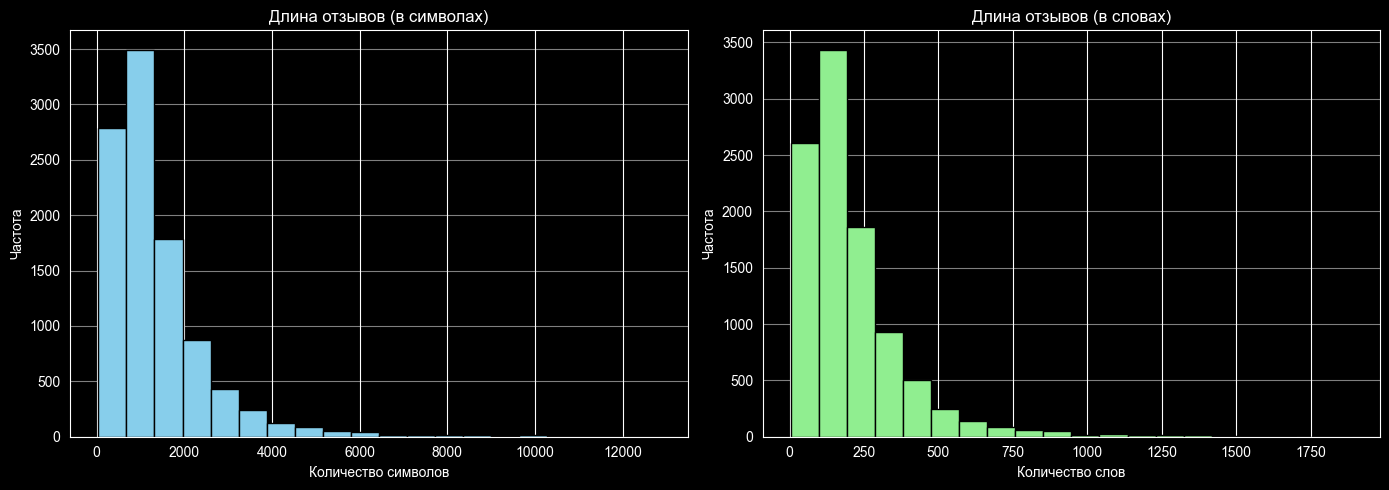

       length_chars  length_words
count  10000.000000   10000.00000
mean    1385.266100     209.69990
std     1198.129411     179.88686
min       41.000000       4.00000
25%      638.000000      96.00000
50%     1047.000000     159.00000
75%     1711.000000     260.00000
max    12837.000000    1889.00000


In [91]:
rating_df['text'] = rating_df['text'].astype(str).str.strip()

rating_df['length_chars'] = rating_df['text'].str.len()
rating_df['length_words'] = rating_df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(rating_df['length_chars'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Длина отзывов (в символах)')
axes[0].set_xlabel('Количество символов')
axes[0].set_ylabel('Частота')
axes[0].grid(axis='y', alpha=0.5)

axes[1].hist(rating_df['length_words'], bins=20, color='lightgreen', edgecolor='black')
axes[1].set_title('Длина отзывов (в словах)')
axes[1].set_xlabel('Количество слов')
axes[1].set_ylabel('Частота')
axes[1].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

print(rating_df[['length_chars', 'length_words']].describe())


In [92]:
import re
from collections import Counter
import pymorphy3
from nltk.corpus import stopwords

morph = pymorphy3.MorphAnalyzer()
stop_words = set(stopwords.words('russian'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^Аа-яЯё\s]', '', text)
    tokens = [t for t in text.split() if len(t) > 1]
    return tokens

texts = rating_df['text'].dropna().astype(str)
all_tokens = []
for txt in texts:
    tokens = preprocess_text(txt)
    all_tokens.extend(tokens)

top_words = Counter(all_tokens).most_common(10)
print("Топ 10 слов:")
for word, count in top_words:
    print(f"{word}: {count}")

tokens_no_stop = [t for t in all_tokens if t not in stop_words]
top_no_stop = Counter(tokens_no_stop).most_common(10)
print("\n Топ 10 слов без стоп-слов:")
for word, count in top_no_stop:
    print(f"{word}: {count}")

lemmas = []
for token in tqdm(all_tokens, desc="Лемматизация"):
    parsed = morph.parse(token)[0]
    lemmas.append(parsed.normal_form)
top_lemmas = Counter(lemmas).most_common(10)
print("\n Топ 10 лемм:")
for lemma, count in top_lemmas:
    print(f"{lemma}: {count}")

nouns = []
for token in tqdm(all_tokens, desc="Поиск существительных"):
    parsed = morph.parse(token)[0]
    if parsed.tag.POS == 'NOUN':
        nouns.append(parsed.normal_form)
top_nouns = Counter(nouns).most_common(10)
print("\n Топ 10 существительных:")
for noun, count in top_nouns:
    print(f"{noun}: {count}")

Топ 10 слов:
не: 49662
на: 41044
что: 35318
по: 22361
мне: 19017
банка: 16655
банк: 12880
но: 10818
как: 10801
меня: 10785

 Топ 10 слов без стоп-слов:
банка: 16655
банк: 12880
это: 10097
деньги: 6980
карты: 5980
карту: 5625
день: 4712
кредит: 4626
заявление: 3931
банке: 3772


Лемматизация: 100%|██████████| 1766955/1766955 [01:21<00:00, 21587.98it/s]



 Топ 10 лемм:
не: 49662
на: 41044
банк: 39243
что: 36738
я: 32249
быть: 24217
по: 22361
карта: 18734
это: 17097
мой: 15964


Поиск существительных: 100%|██████████| 1766955/1766955 [01:23<00:00, 21197.86it/s]



 Топ 10 существительных:
банк: 39243
карта: 18734
день: 10026
кредит: 9710
деньга: 9472
сотрудник: 9346
клиент: 7794
счёт: 7743
сумма: 6978
отделение: 6887


кривые Ципфа и Хипса

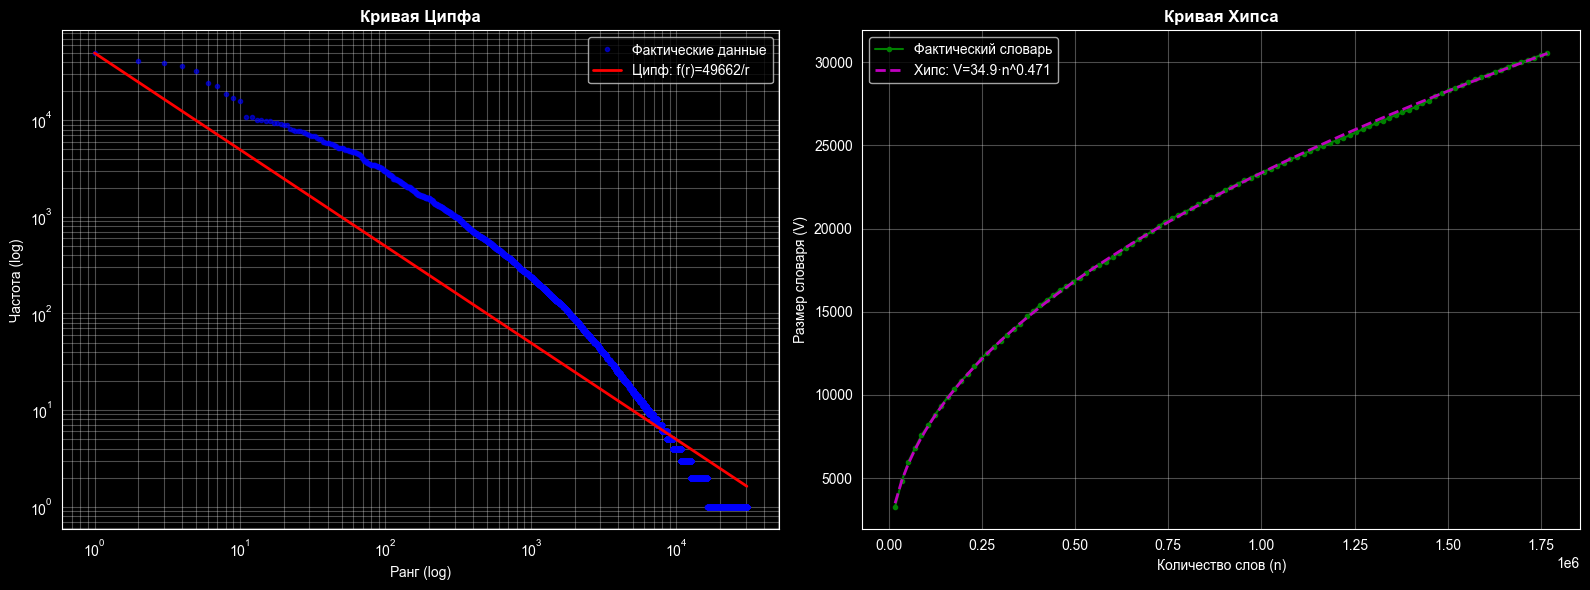

Уникальных лемм: 30550
Всего токенов: 1766955
Параметры Хипса: β=0.471, K=34.87


In [93]:
texts = rating_df['text'].dropna().astype(str)
all_tokens = []
all_lemmas = []

for txt in texts:
    tokens = preprocess_text(txt)
    all_tokens.extend(tokens)
    for token in tokens:
        parsed = morph.parse(token)[0]
        all_lemmas.append(parsed.normal_form)

# Кривая Ципфа
lemma_counts = Counter(all_lemmas)
sorted_freqs = sorted(lemma_counts.values(), reverse=True)
ranks = np.arange(1, len(sorted_freqs) + 1)

C = sorted_freqs[0] if sorted_freqs else 1
zipf_theoretical = C / ranks

# Кривая Хипса
vocab_sizes = []
unique_words = set()
step = builtins.max(1, len(all_lemmas) // 100)

for i, lemma in enumerate(all_lemmas, 1):
    unique_words.add(lemma)
    if i % step == 0:
        vocab_sizes.append((i, len(unique_words)))

heap_n = np.array([x[0] for x in vocab_sizes])
heap_v = np.array([x[1] for x in vocab_sizes])

log_n = np.log(heap_n[heap_n > 0])
log_v = np.log(heap_v[heap_n > 0])

if len(log_n) > 1:
    beta, log_K = np.polyfit(log_n, log_v, 1)
    K = np.exp(log_K)
    heap_theoretical = K * heap_n ** beta
else:
    beta, K = 0, 0
    heap_theoretical = heap_n

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Кривая Ципфа
axes[0].loglog(ranks, sorted_freqs, 'bo', markersize=3, label='Фактические данные', alpha=0.6)
axes[0].loglog(ranks, zipf_theoretical, 'r-', linewidth=2, label=f'Ципф: f(r)={C:.0f}/r')
axes[0].set_xlabel('Ранг (log)')
axes[0].set_ylabel('Частота (log)')
axes[0].set_title('Кривая Ципфа', fontweight='bold')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

# Кривая Хипса
axes[1].plot(heap_n, heap_v, 'go-', markersize=3, label='Фактический словарь')
if beta != 0:
    axes[1].plot(heap_n, heap_theoretical, 'm--', linewidth=2,
                 label=f'Хипс: V={K:.1f}·n^{beta:.3f}')
axes[1].set_xlabel('Количество слов (n)')
axes[1].set_ylabel('Размер словаря (V)')
axes[1].set_title('Кривая Хипса', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Уникальных лемм: {len(lemma_counts)}")
print(f"Всего токенов: {len(all_lemmas)}")
print(f"Параметры Хипса: β={beta:.3f}, K={K:.2f}")

In [94]:
lemma_counts = Counter(all_lemmas)

staff_count = lemma_counts.get('сотрудник', 0)
customer_count = lemma_counts.get('клиент', 0)

print("Сравнение частот:")
print(f"   'сотрудник': {staff_count}")
print(f"   'клиент':    {customer_count}")
if staff_count > customer_count:
    print(f"Чаще встречается: 'сотрудник' (на {staff_count - customer_count})")
elif klient_count > sotrudnik_count:
    print(f"Чаще встречается: 'клиент' (на {customer_count - staff_count})")
else:
    print(f"Одинаково")

fraud_count = lemma_counts.get('мошенничество', 0)
trust_count = lemma_counts.get('доверие', 0)

print("\n Частотa слов:")
print(f"   'мошенничество': {fraud_count}")
print(f"   'доверие':       {trust_count}")

for word in ['сотрудник', 'клиент', 'мошенничество', 'доверие']:
    count = lemma_counts.get(word, 0)
    if count > 0:
        print(f"\n'{word}' ({count} раз):")

Сравнение частот:
   'сотрудник': 9346
   'клиент':    7794
Чаще встречается: 'сотрудник' (на 1552)

 Частотa слов:
   'мошенничество': 220
   'доверие':       152

'сотрудник' (9346 раз):

'клиент' (7794 раз):

'мошенничество' (220 раз):

'доверие' (152 раз):


In [95]:
df_pos = rating_df[rating_df['rating_grade'] == 5]['text'].dropna().astype(str)
df_neg = rating_df[rating_df['rating_grade'] == 1]['text'].dropna().astype(str)

print(f"Положительных отзывов - 5: {len(df_pos)}")
print(f"Отрицательных отзывов - 1: {len(df_neg)}")

# === Предобработка ===
pos_texts = [preprocess_text(t) for t in df_pos]
neg_texts = [preprocess_text(t) for t in df_neg]

def get_top_tfidf(texts, n_top=15, ngram_range=(1,1)):
    if not texts or all(len(t.strip()) == 0 for t in texts):
        return []

    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=1000,
        min_df=1,
        max_df=0.95
    )
    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()

    mean_tfidf = tfidf_matrix.mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-n_top:][::-1]

    return [(feature_names[i], mean_tfidf[i]) for i in top_idx]

print("Положительные отзывы - 5")

print("\nТоп-15 униморф:")
for word, score in get_top_tfidf(pos_texts, n_top=15, ngram_range=(1,1)):
    print(f"   {word:20s} → TF-IDF: {score:.4f}")

print("\nТоп-15 биграмм:")
for bigram, score in get_top_tfidf(pos_texts, n_top=15, ngram_range=(2,2)):
    print(f"   {bigram:25s} → TF-IDF: {score:.4f}")

print("Отрицательные отзывы - 1")

print("\n Топ-15 униморф:")
for word, score in get_top_tfidf(neg_texts, n_top=15, ngram_range=(1,1)):
    print(f"   {word:20s} → TF-IDF: {score:.4f}")

print("\n Топ-15 биграмм:")
for bigram, score in get_top_tfidf(neg_texts, n_top=15, ngram_range=(2,2)):
    print(f"   {bigram:25s} → TF-IDF: {score:.4f}")

Положительных отзывов - 5: 471
Отрицательных отзывов - 1: 2585
Положительные отзывы - 5

Топ-15 униморф:

Топ-15 биграмм:
Отрицательные отзывы - 1

 Топ-15 униморф:

 Топ-15 биграмм:


In [96]:
from gensim import corpora, models

morph = pymorphy3.MorphAnalyzer()
stop_words = set(stopwords.words('russian'))

def clean(t):
    t = re.sub(r'[^а-яё\s]', '', str(t).lower())
    return [morph.parse(w)[0].normal_form for w in t.split() if len(w)>2 and w not in stop_words]

docs = [clean(t) for t in rating_df['text'].dropna() if clean(t)]
dic = corpora.Dictionary(docs)
corpus = [dic.doc2bow(d) for d in docs]

lda = models.LdaModel(corpus=corpus, id2word=dic, num_topics=10, passes=5)

print("Темы:")
for i, topic in lda.show_topics(num_words=5):
    print(f"Тема {i}: {topic}")

Темы:
Тема 0: 0.033*"банк" + 0.030*"карта" + 0.016*"это" + 0.012*"деньга" + 0.008*"проблема"
Тема 1: 0.020*"отделение" + 0.019*"банк" + 0.014*"сотрудник" + 0.012*"офис" + 0.011*"клиент"
Тема 2: 0.036*"банк" + 0.021*"номер" + 0.020*"звонок" + 0.019*"мой" + 0.018*"сотрудник"
Тема 3: 0.037*"ставка" + 0.017*"банк" + 0.013*"процентный" + 0.006*"это" + 0.005*"закладная"
Тема 4: 0.053*"карта" + 0.021*"деньга" + 0.020*"банк" + 0.016*"мой" + 0.014*"заявление"
Тема 5: 0.047*"кредит" + 0.028*"банк" + 0.022*"страховка" + 0.021*"договор" + 0.016*"сумма"
Тема 6: 0.040*"банк" + 0.030*"кредит" + 0.021*"платёж" + 0.017*"сумма" + 0.015*"кредитный"
Тема 7: 0.050*"банк" + 0.044*"вклад" + 0.019*"счёт" + 0.011*"комиссия" + 0.010*"процент"
Тема 8: 0.038*"банк" + 0.030*"договор" + 0.017*"средство" + 0.014*"денежный" + 0.011*"право"
Тема 9: 0.022*"банк" + 0.019*"документ" + 0.011*"заявка" + 0.011*"это" + 0.010*"день"


In [97]:
bank_names = ['сбербанк', 'втб', 'альфа', 'тинькофф', 'газаринский', 'бинбанк', 'восточный', 'мтс']

docs = [clean(t) for t in rating_df['text'].dropna() if clean(t)]
dic = corpora.Dictionary(docs)
corpus = [dic.doc2bow(d) for d in docs]

lda = models.LdaModel(corpus=corpus, id2word=dic, num_topics=10, passes=5, random_state=42)

print("Все темы:")
for i, topic in lda.show_topics(num_words=8, formatted=False):
    words = [w for w, _ in topic]
    print(f"Тема {i}: {', '.join(words)}")

print("Темы с упоминанием банков:")

bank_topics = {}

for topic_id in range(10):
    topic_words = lda.show_topic(topic_id, topn=15)
    words_list = [w for w, _ in topic_words]

    for bank in bank_names:
        if bank in words_list:
            if bank not in bank_topics:
                bank_topics[bank] = []
            bank_topics[bank].append((topic_id, topic_words))

if bank_topics:
    for bank, topics in bank_topics.items():
        print(f"\n {bank.upper()}:")
        for topic_id, topic_words in topics:
            print(f"Тема {topic_id}:")
            for word, prob in topic_words[:8]:
                print(f"{word:20s} → {prob:.4f}")
else:
    print("\n Банки не найдены в топ-словах тем.")

print("Частота банков в отзывах:")

for bank in bank_names:
    count = rating_df['text'].astype(str).str.lower().str.contains(bank, na=False).sum()
    if count > 0:
        print(f"   {bank}: {count} отзывов")

if bank_topics:
    print("Примеры отзывов:")

    for bank, topics in list(bank_topics.items())[:3]:
        topic_id = topics[0][0]

        for doc_id, doc in enumerate(corpus[:100]):
            topic_dist = lda.get_document_topics(doc)
            dominant = builtins.max(topic_dist, key=lambda x: x[1])

            if dominant[0] == topic_id:
                text = rating_df['text'].iloc[doc_id] if doc_id < len(rating_df) else ""
                if text:
                    print(f"\n {bank.upper()} (Тема {topic_id}):")
                    print(f"   {text[:150]}...")
                    break

Все темы:
Тема 0: банк, звонок, номер, мой, телефон, ваш, сотрудник, звонить
Тема 1: банк, это, клиент, отделение, свой, который, время, очередь
Тема 2: кредит, банк, договор, сумма, платёж, кредитный, год, сотрудник
Тема 3: вклад, банк, договор, процент, условие, ставка, открыть, сумма
Тема 4: документ, доверенность, копия, пакет, паспорт, нотариус, подпись, печать
Тема 5: банк, сказать, отделение, день, заявление, карта, позвонить, сотрудник
Тема 6: банк, сотрудник, вопрос, клиент, спасибо, очень, мой, наш
Тема 7: карта, банк, это, счёт, который, мой, клиент, услуга
Тема 8: деньга, банкомат, день, карта, счёт, сумма, терминал, проблема
Тема 9: банк, средство, счёт, денежный, мой, сбербанк, заявление, операция
Темы с упоминанием банков:

 СБЕРБАНК:
Тема 9:
банк                 → 0.0296
средство             → 0.0262
счёт                 → 0.0198
денежный             → 0.0187
мой                  → 0.0184
сбербанк             → 0.0164
заявление            → 0.0133
операция             →

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

df_pos = rating_df[rating_df['rating_grade'] == 5][['text', 'rating_grade']].dropna()
df_neg = rating_df[rating_df['rating_grade'] == 1][['text', 'rating_grade']].dropna()

# по 500 отзывов каждого типа
N1 = 500 if len(df_neg) >= 500 else len(df_neg)
N2 = 500 if len(df_pos) >= 500 else len(df_pos)

data = pd.concat([df_neg.head(N1), df_pos.head(N2)])
data['label'] = (data['rating_grade'] == 5).astype(int)

X = data['text'].astype(str)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Отрицательных (1): {N1}, Положительных (5): {N2}")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")


def evaluate(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"{name:30s} → Accuracy: {acc:.3f}, F1: {f1:.3f}")
    return acc, f1

vec_uni = TfidfVectorizer(ngram_range=(1,1), max_features=5000)
X_train_uni = vec_uni.fit_transform(X_train)
X_test_uni = vec_uni.transform(X_test)
clf = LogisticRegression(max_iter=1000, random_state=42)
evaluate(clf, X_train_uni, X_test_uni, y_train, y_test, "TF-IDF униграммы")

vec_bi = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
X_train_bi = vec_bi.fit_transform(X_train)
X_test_bi = vec_bi.transform(X_test)
evaluate(clf, X_train_bi, X_test_bi, y_train, y_test, "TF-IDF униграммы + биграммы")

vec_tri = TfidfVectorizer(ngram_range=(1,3), max_features=5000)
X_train_tri = vec_tri.fit_transform(X_train)
X_test_tri = vec_tri.transform(X_test)
evaluate(clf, X_train_tri, X_test_tri, y_train, y_test, "TF-IDF до триграмм")

vec_char = TfidfVectorizer(analyzer='char', ngram_range=(3,5), max_features=5000)
X_train_char = vec_char.fit_transform(X_train)
X_test_char = vec_char.transform(X_test)
evaluate(clf, X_train_char, X_test_char, y_train, y_test, "TF-IDF символьные n-граммы")

tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

svd = TruncatedSVD(n_components=50, random_state=42)
X_train_lsa = svd.fit_transform(X_train_tfidf)
X_test_lsa = svd.transform(X_test_tfidf)
evaluate(clf, X_train_lsa, X_test_lsa, y_train, y_test, "TF-IDF + LSA (50 тем)")

lda = LatentDirichletAllocation(n_components=50, random_state=42, max_iter=10)
X_train_lda = lda.fit_transform(X_train_tfidf)
X_test_lda = lda.transform(X_test_tfidf)
evaluate(clf, X_train_lda, X_test_lda, y_train, y_test, "TF-IDF + LDA (50 тем)")

Отрицательных (1): 500, Положительных (5): 471
Train: 776, Test: 195
TF-IDF униграммы               → Accuracy: 0.892, F1: 0.884
TF-IDF униграммы + биграммы    → Accuracy: 0.908, F1: 0.901
TF-IDF до триграмм             → Accuracy: 0.908, F1: 0.901
TF-IDF символьные n-граммы     → Accuracy: 0.887, F1: 0.882
TF-IDF + LSA (50 тем)          → Accuracy: 0.882, F1: 0.874
TF-IDF + LDA (50 тем)          → Accuracy: 0.631, F1: 0.507


(0.6307692307692307, 0.5068493150684932)